In [1]:
# Cell 1: Setup & Data Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from glob import glob
import seaborn as sns
from PIL import Image

sns.set_style('darkgrid')

DATA_DIR = '../input/skin-cancer-mnist-ham10000'

all_image_path = glob(os.path.join(DATA_DIR, '*', '*.jpg'))

imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in all_image_path}

lesion_type_dict = {
    'nv': 'Melanocytic nevi (Moles)',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

print(f" تم التجهيز! عدد الصور التي تم العثور عليها: {len(all_image_path)}")

✅ تم التجهيز! عدد الصور التي تم العثور عليها: 20030


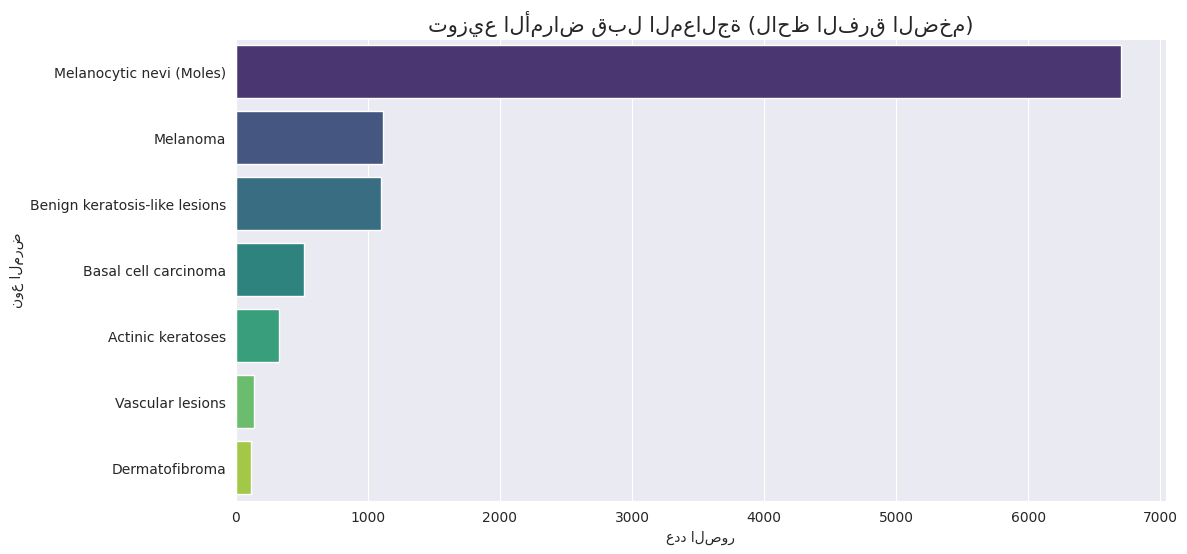

الأعداد بالضبط:
cell_type
Melanocytic nevi (Moles)         6705
Melanoma                         1113
Benign keratosis-like lesions    1099
Basal cell carcinoma              514
Actinic keratoses                 327
Vascular lesions                  142
Dermatofibroma                    115
Name: count, dtype: int64


In [2]:
# Cell 2: Exploratory Data Analysis (EDA)

df = pd.read_csv(os.path.join(DATA_DIR, 'HAM10000_metadata.csv'))

df['path'] = df['image_id'].map(imageid_path_dict.get)
df['cell_type'] = df['dx'].map(lesion_type_dict.get)
df['cell_type_idx'] = pd.Categorical(df['cell_type']).codes 

plt.figure(figsize=(12, 6))
sns.countplot(y='cell_type', data=df, order=df['cell_type'].value_counts().index, palette='viridis')
plt.title('توزيع الأمراض قبل المعالجة (لاحظ الفرق الضخم)', fontsize=15)
plt.xlabel('عدد الصور')
plt.ylabel('نوع المرض')
plt.show()

print("الأعداد بالضبط:")
print(df['cell_type'].value_counts())

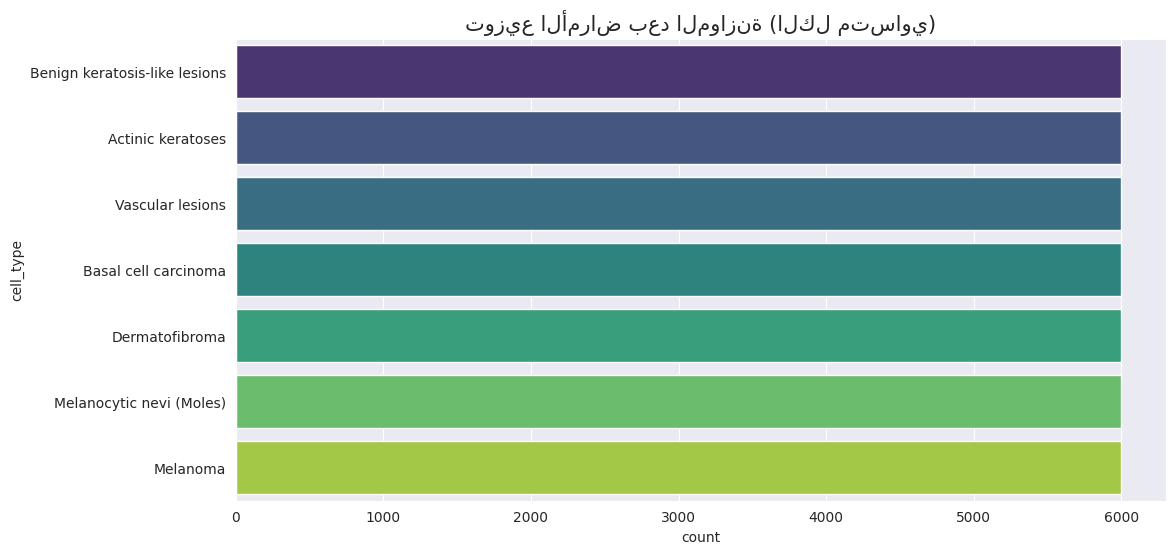

✅ البيانات جاهزة! العدد الكلي للصور الآن: 42000


In [3]:
# Cell 3: Balancing Data (Over-sampling)
from sklearn.utils import resample

Target_Count = 6000

df_balanced_list = []

for idx in df['cell_type_idx'].unique():
    group = df[df['cell_type_idx'] == idx]
    resampled = resample(group, replace=True, n_samples=Target_Count, random_state=42)
    df_balanced_list.append(resampled)

df_balanced = pd.concat(df_balanced_list)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True) 

plt.figure(figsize=(12, 6))
sns.countplot(y='cell_type', data=df_balanced, order=df_balanced['cell_type'].value_counts().index, palette='viridis')
plt.title('توزيع الأمراض بعد الموازنة (الكل متساوي)', fontsize=15)
plt.show()

print(f" البيانات جاهزة! العدد الكلي للصور الآن: {len(df_balanced)}")

In [4]:
# Cell 4: Preparing Data Loaders
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df_balanced, test_size=0.2, random_state=42)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class SkinDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        row = self.df.iloc[index]
        image = Image.open(row['path']).convert('RGB')
        label = torch.tensor(row['cell_type_idx'], dtype=torch.long)
        
        if self.transform:
            image = self.transform(image)
        return image, label

BATCH_SIZE = 32
train_ds = SkinDataset(train_df, transform=train_transform)
val_ds = SkinDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(" تم تجهيز المولدات (Data Loaders).")

✅ تم تجهيز المولدات (Data Loaders).


In [5]:
# Cell 5: Model Setup (ResNet50)
from torchvision import models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"سنعمل على المعالج: {device}")

model = models.resnet50(pretrained=True)

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 7) # 7 classes

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001) 

print(" تم بناء الموديل ResNet50 بنجاح.")

سنعمل على المعالج: cuda


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]


✅ تم بناء الموديل ResNet50 بنجاح.


In [6]:
# Cell 6: Training
num_epochs = 5
train_losses, val_losses = [], []
train_acc, val_acc = [], []

print(" بدء التدريب...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)
    
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_epoch_loss = val_running_loss / len(val_loader)
    val_epoch_acc = 100 * val_correct / val_total
    val_losses.append(val_epoch_loss)
    val_acc.append(val_epoch_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% | "
          f"Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.2f}%")

print(" انتهى التدريب!")

torch.save(model.state_dict(), 'skin_resnet50.pth')
print(" تم حفظ الموديل باسم skin_resnet50.pth")

🚀 بدء التدريب...
Epoch [1/5] Train Loss: 0.3760 Acc: 86.59% | Val Loss: 0.2146 Acc: 92.25%
Epoch [2/5] Train Loss: 0.1573 Acc: 94.60% | Val Loss: 0.1004 Acc: 96.27%
Epoch [3/5] Train Loss: 0.1044 Acc: 96.49% | Val Loss: 0.0788 Acc: 97.00%
Epoch [4/5] Train Loss: 0.0865 Acc: 97.06% | Val Loss: 0.0635 Acc: 98.00%
Epoch [5/5] Train Loss: 0.0619 Acc: 97.94% | Val Loss: 0.0421 Acc: 98.55%
✅ انتهى التدريب!
💾 تم حفظ الموديل باسم skin_resnet50.pth


In [7]:
import pandas as pd

mapping_df = df[['cell_type_idx', 'cell_type']].drop_duplicates().sort_values('cell_type_idx')

label_mapping = dict(zip(mapping_df['cell_type_idx'], mapping_df['cell_type']))

print(" هام جداً: انسخ هذا الترتيب لاستخدامه في التطبيق:")
print("---------------------------------------------------")
for idx, name in label_mapping.items():
    print(f"{idx}: '{name}',")
print("---------------------------------------------------")

⚠️ هام جداً: انسخ هذا الترتيب لاستخدامه في التطبيق:
---------------------------------------------------
0: 'Actinic keratoses',
1: 'Basal cell carcinoma',
2: 'Benign keratosis-like lesions',
3: 'Dermatofibroma',
4: 'Melanocytic nevi (Moles)',
5: 'Melanoma',
6: 'Vascular lesions',
---------------------------------------------------


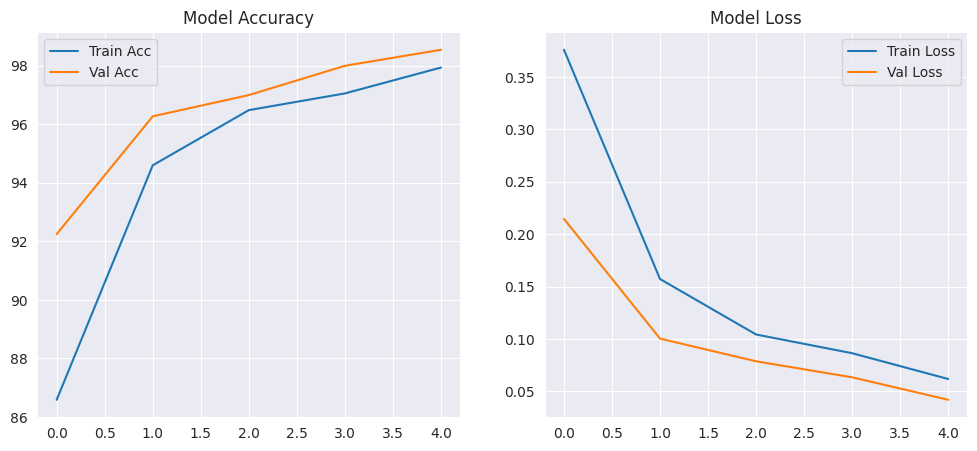

In [8]:
# Cell 7: Training Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

1. جاري تحميل الصورة من الإنترنت...
   ✅ تم تحميل الصورة بنجاح.
2. جاري المعالجة والفحص...

🔴 التشخيص: Melanocytic nevi (Moles)
📊 الثقة: 93.81%


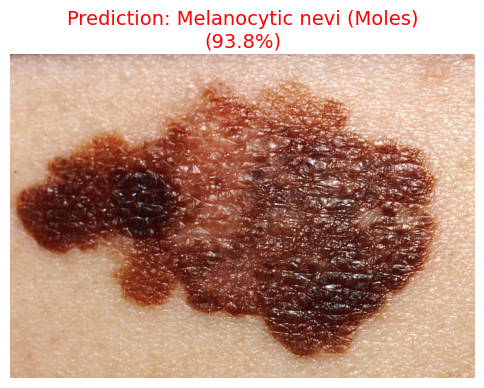

In [9]:
# Cell 8  اختبار الموديل على صورة خارجية
import requests
from PIL import Image
from io import BytesIO
import torch
from torchvision import transforms
import matplotlib.pyplot as plt

LABELS = {
    0: 'Actinic keratoses',
    1: 'Basal cell carcinoma',
    2: 'Benign keratosis-like lesions',
    3: 'Dermatofibroma',
    4: 'Melanocytic nevi (Moles)',
    5: 'Melanoma',
    6: 'Vascular lesions',
}


image_url = "https://upload.wikimedia.org/wikipedia/commons/6/6c/Melanoma.jpg"

def test_online_image(url):
    print("1. جاري تحميل الصورة من الإنترنت...")
    
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
    
    try:
        response = requests.get(url, headers=headers, stream=True)
        response.raise_for_status() 
        img = Image.open(BytesIO(response.content)).convert('RGB')
        print("    تم تحميل الصورة بنجاح.")
        
    except Exception as e:
        print(f"    فشل تحميل الصورة: {e}")
        return

    print("2. جاري المعالجة والفحص...")
    # التجهيز (Preprocessing)
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    input_tensor = preprocess(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        top_prob, top_class = torch.topk(probabilities, 1)
 
    idx = top_class.item()
    score = top_prob.item() * 100
    result_name = LABELS[idx]
    
    print("\n" + "="*30)
    print(f" التشخيص: {result_name}")
    print(f" الثقة: {score:.2f}%")
    print("="*30)
    
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(f"Prediction: {result_name}\n({score:.1f}%)", color='red', fontsize=14)
    plt.axis('off')
    plt.show()

test_online_image(image_url)

🔄 جاري فحص بيانات الاختبار (Validation Set)...
✅ تم جمع التوقعات.


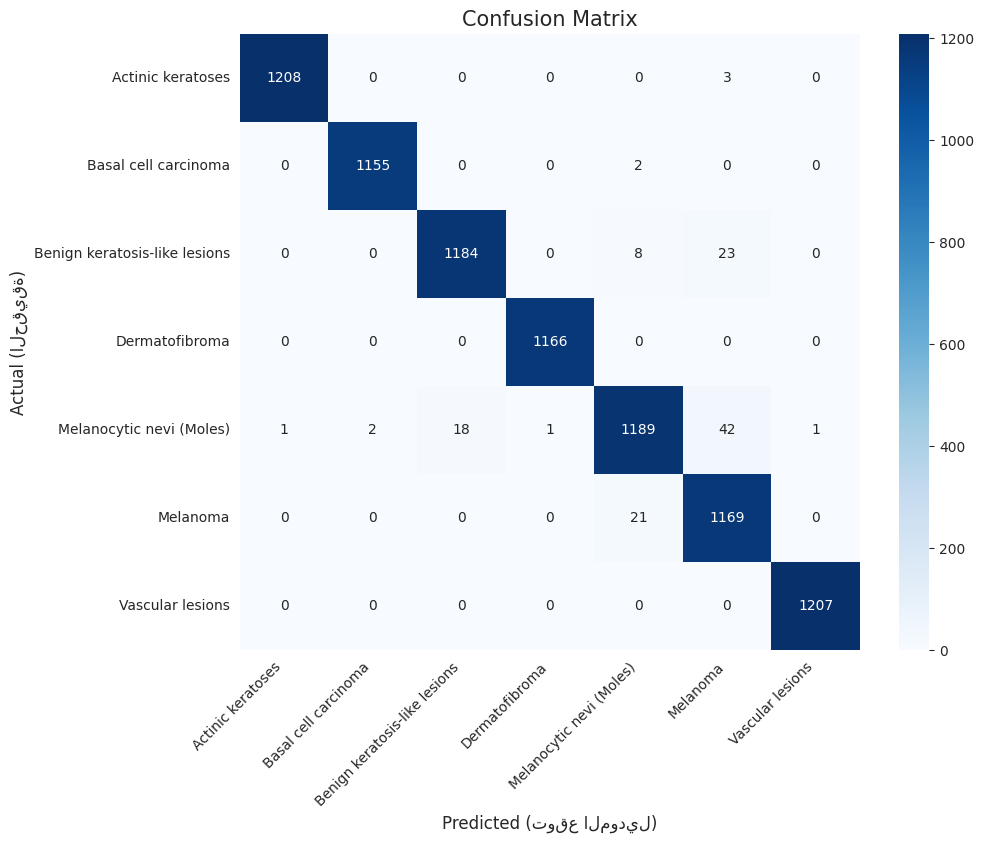


📊 Classification Report
                               precision    recall  f1-score   support

            Actinic keratoses       1.00      1.00      1.00      1211
         Basal cell carcinoma       1.00      1.00      1.00      1157
Benign keratosis-like lesions       0.99      0.97      0.98      1215
               Dermatofibroma       1.00      1.00      1.00      1166
     Melanocytic nevi (Moles)       0.97      0.95      0.96      1254
                     Melanoma       0.95      0.98      0.96      1190
             Vascular lesions       1.00      1.00      1.00      1207

                     accuracy                           0.99      8400
                    macro avg       0.99      0.99      0.99      8400
                 weighted avg       0.99      0.99      0.99      8400

⭐ Weighted F1 Score: 0.9855


In [10]:
# Cell 9  Confusion Matrix & F1 Score
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np

class_names = [
    'Actinic keratoses',             # 0
    'Basal cell carcinoma',          # 1
    'Benign keratosis-like lesions', # 2
    'Dermatofibroma',                # 3
    'Melanocytic nevi (Moles)',      # 4
    'Melanoma',                      # 5
    'Vascular lesions'               # 6
]

y_true = []
y_pred = []

print(" جاري فحص بيانات الاختبار (Validation Set)...")

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(" تم جمع التوقعات.")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted (توقع الموديل)', fontsize=12)
plt.ylabel('Actual (الحقيقة)', fontsize=12)
plt.title('Confusion Matrix', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.show()

print("\n" + "="*60)
print(" Classification Report")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))

f1 = f1_score(y_true, y_pred, average='weighted')
print(f" Weighted F1 Score: {f1:.4f}")
print("="*60)

🔄 جاري حساب احتمالات الـ ROC...

📊 نتائج AUC لكل مرض:
------------------------------
✅ Actinic keratoses: AUC = 1.0000
✅ Basal cell carcinoma: AUC = 1.0000
✅ Benign keratosis-like lesions: AUC = 0.9998
✅ Dermatofibroma: AUC = 1.0000
✅ Melanocytic nevi (Moles): AUC = 0.9982
✅ Melanoma: AUC = 0.9992
✅ Vascular lesions: AUC = 1.0000
------------------------------
⭐ Average AUC (Macro): 0.9996


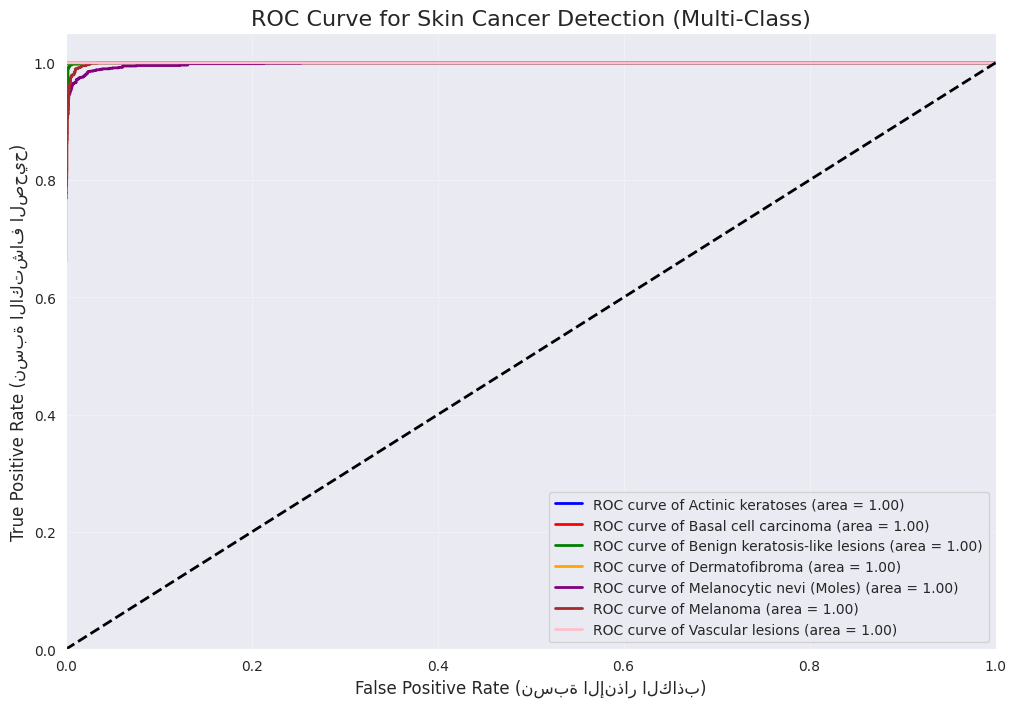

In [11]:
# Cell 10: ROC Curve & AUC Score (Multi-class)
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle


y_test_binarized = [] 
y_score = []           

print(" جاري حساب احتمالات الـ ROC...")

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)

        y_test_binarized.extend(labels.cpu().numpy())
        y_score.extend(probs.cpu().numpy())

y_test_binarized = label_binarize(y_test_binarized, classes=[0, 1, 2, 3, 4, 5, 6])
y_score = np.array(y_score)
n_classes = 7

fpr = dict()
tpr = dict()
roc_auc = dict()

print("\n نتائج AUC لكل مرض:")
print("-" * 30)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    print(f" {class_names[i]}: AUC = {roc_auc[i]:.4f}")

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)

print("-" * 30)
print(f" Average AUC (Macro): {macro_auc:.4f}")

plt.figure(figsize=(12, 8))

colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (نسبة الإنذار الكاذب)', fontsize=12)
plt.ylabel('True Positive Rate (نسبة الاكتشاف الصحيح)', fontsize=12)
plt.title('ROC Curve for Skin Cancer Detection (Multi-Class)', fontsize=16)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [12]:
from IPython.display import FileLink


FileLink(r'skin_resnet50.pth')

/kaggle/working/skin_resnet50.pth